In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")
sns.set_palette("Set2")

print("Netflix EDA — Let's go! 🎬")

Netflix EDA — Let's go! 🎬


In [2]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [3]:
# Load dataset
df = pd.read_csv('netflix_titles.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nMissing Percentages:")
print((df.isnull().sum() / len(df) * 100).round(2))

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing Percentages:
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


In [5]:
# Exact percentages
missing = (df.isnull().sum() / len(df) * 100).round(2)
print(missing[missing > 0])

director      29.91
cast           9.37
country        9.44
date_added     0.11
rating         0.05
duration       0.03
dtype: float64


In [6]:
# Handle missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df = df.dropna(subset=['duration'])

# Verify
print("Missing after cleaning:")
print(df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Missing after cleaning:
0
Shape after cleaning: (8804, 12)


In [7]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Verify
print(df[['date_added', 'year_added', 'month_added']].head())

  date_added  year_added month_added
0 2021-09-25        2021   September
1 2021-09-24        2021   September
2 2021-09-24        2021   September
3 2021-09-24        2021   September
4 2021-09-24        2021   September


In [8]:
print(df['duration'].value_counts().head(10))
print("\nUnique duration examples:")
print(df['duration'].unique()[:10])

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
97 min        146
94 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64

Unique duration examples:
['90 min' '2 Seasons' '1 Season' '91 min' '125 min' '9 Seasons' '104 min'
 '127 min' '4 Seasons' '67 min']


In [10]:
# Separate duration into numeric value and unit
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)')

# Verify
print(df[['type', 'duration', 'duration_value', 'duration_unit']].head(10))

      type   duration  duration_value duration_unit
0    Movie     90 min            90.0           min
1  TV Show  2 Seasons             2.0       Seasons
2  TV Show   1 Season             1.0        Season
3  TV Show   1 Season             1.0        Season
4  TV Show  2 Seasons             2.0       Seasons
5  TV Show   1 Season             1.0        Season
6    Movie     91 min            91.0           min
7    Movie    125 min           125.0           min
8  TV Show  9 Seasons             9.0       Seasons
9    Movie    104 min           104.0           min


In [11]:
print("Final shape:", df.shape)
print("\nAll columns:", df.columns.tolist())

Final shape: (8804, 16)

All columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'duration_value', 'duration_unit']


In [12]:
print("New columns added:")
print(df[['date_added', 'year_added', 'month_added',
          'duration', 'duration_value', 'duration_unit']].head())
print("\nFinal shape:", df.shape)
print("Total columns:", df.shape[1])

New columns added:
  date_added  year_added month_added   duration  duration_value duration_unit
0 2021-09-25        2021   September     90 min            90.0           min
1 2021-09-24        2021   September  2 Seasons             2.0       Seasons
2 2021-09-24        2021   September   1 Season             1.0        Season
3 2021-09-24        2021   September   1 Season             1.0        Season
4 2021-09-24        2021   September  2 Seasons             2.0       Seasons

Final shape: (8804, 16)
Total columns: 16


In [13]:
# Movies vs TV Shows
print(df['type'].value_counts())
print(df['type'].value_counts(normalize=True).round(3))

type
Movie      6128
TV Show    2676
Name: count, dtype: int64
type
Movie      0.696
TV Show    0.304
Name: proportion, dtype: float64


In [15]:
import os
os.makedirs('screenshots', exist_ok=True)

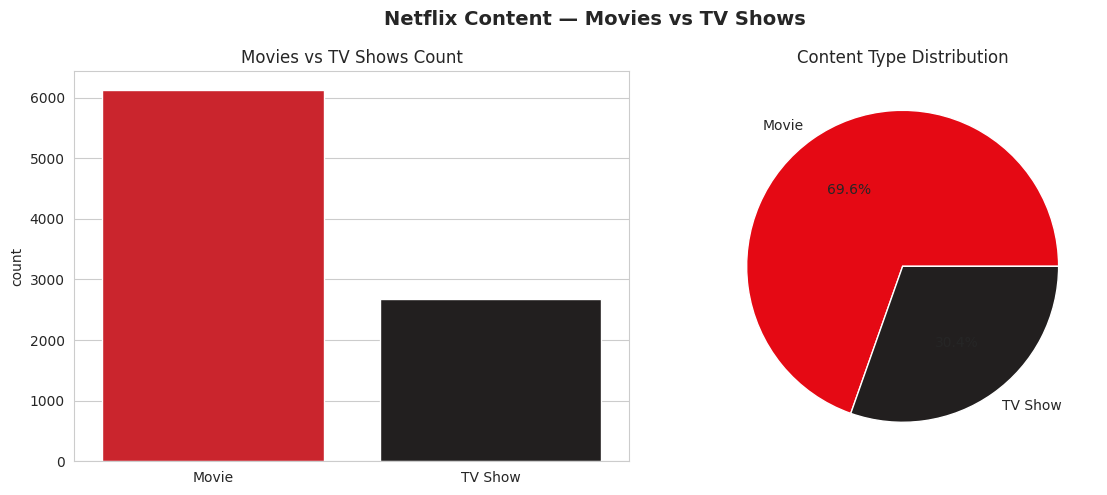

Chart 1 saved! ✅


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='type', hue='type',
              palette={'Movie':'#E50914', 'TV Show':'#221F1F'},
              ax=axes[0])
axes[0].set_title("Movies vs TV Shows Count")
axes[0].set_xlabel("")

# Pie chart
df['type'].value_counts().plot(
    kind='pie',
    colors=['#E50914', '#221F1F'],
    autopct='%1.1f%%',
    ax=axes[1])
axes[1].set_title("Content Type Distribution")
axes[1].set_ylabel("")

plt.suptitle("Netflix Content — Movies vs TV Shows",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('screenshots/01_content_type.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 1 saved! ✅")

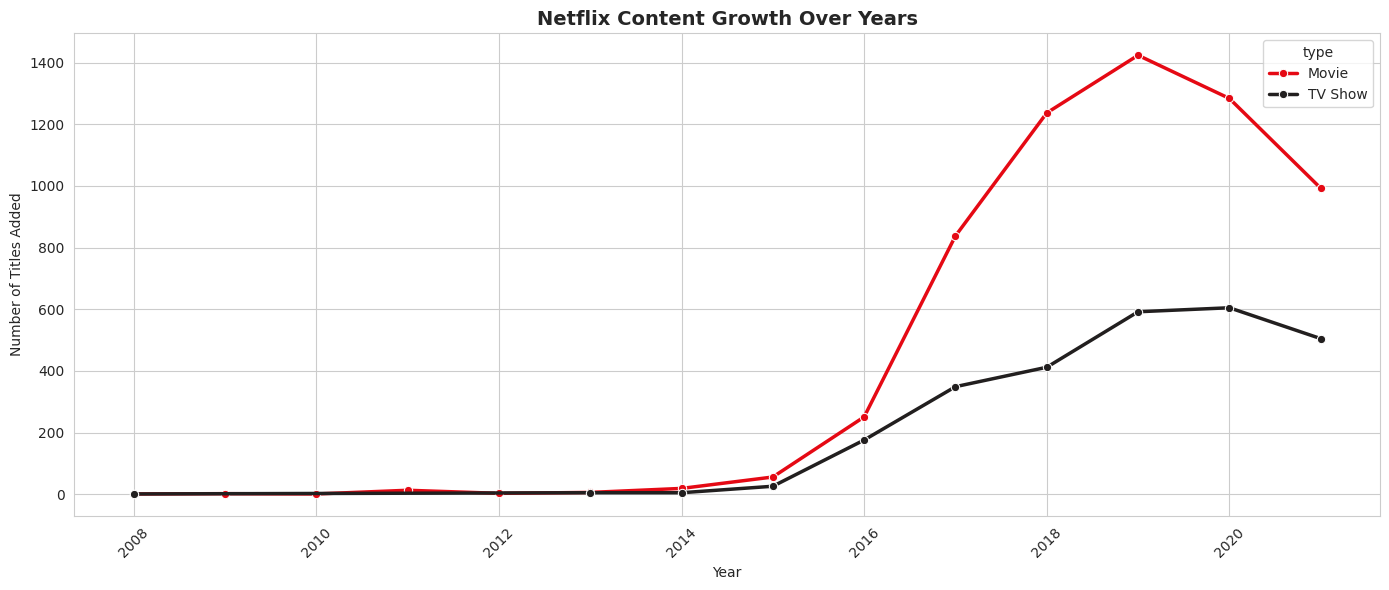

Chart 2 saved! ✅


In [17]:
# Content added per year
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly, x='year_added', y='count',
             hue='type',
             palette={'Movie':'#E50914', 'TV Show':'#221F1F'},
             marker='o', linewidth=2.5)

plt.title("Netflix Content Growth Over Years",
          fontweight='bold', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('screenshots/02_content_growth.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 2 saved! ✅")

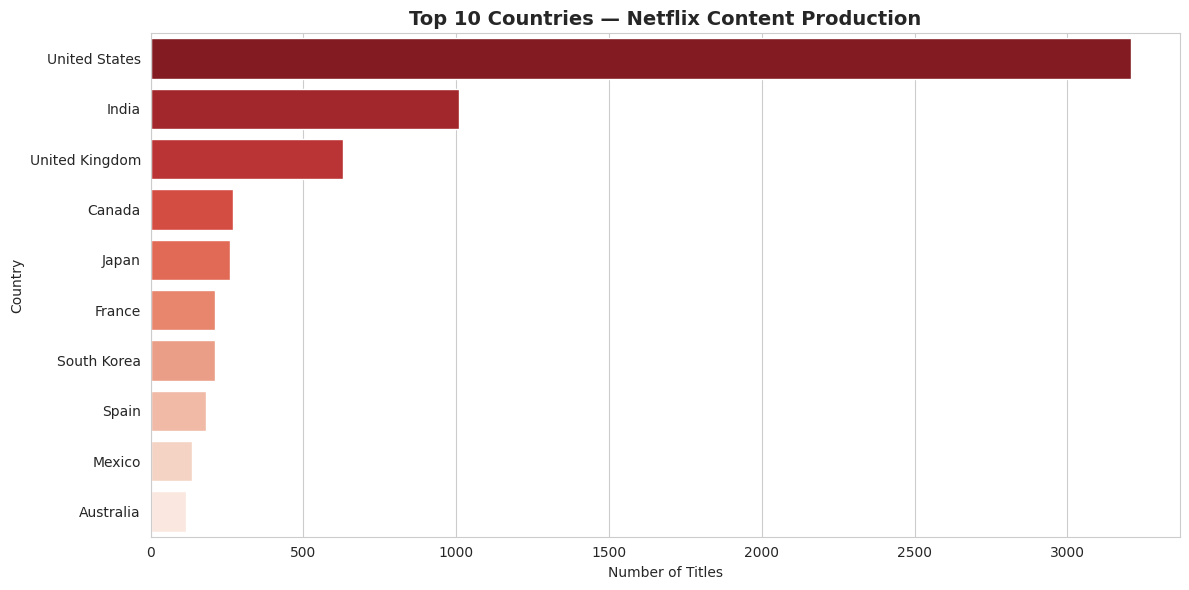

Chart 3 saved! ✅


In [18]:
# Top 10 countries
# Some entries have multiple countries — take first one
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()

country_counts = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values,
            y=country_counts.index,
            hue=country_counts.index,
            palette='Reds_r')

plt.title("Top 10 Countries — Netflix Content Production",
          fontweight='bold', fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig('screenshots/03_top_countries.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 3 saved! ✅")

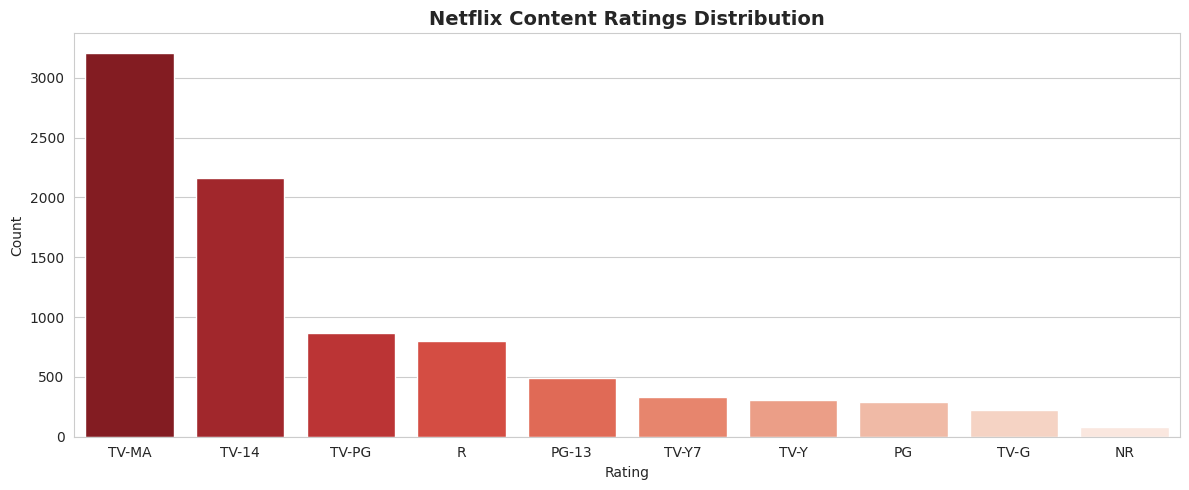

Chart 4 saved! ✅


In [19]:
# Rating distribution
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=rating_counts.index,
            y=rating_counts.values,
            hue=rating_counts.index,
            palette='Reds_r')

plt.title("Netflix Content Ratings Distribution",
          fontweight='bold', fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('screenshots/04_ratings.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 4 saved! ✅")

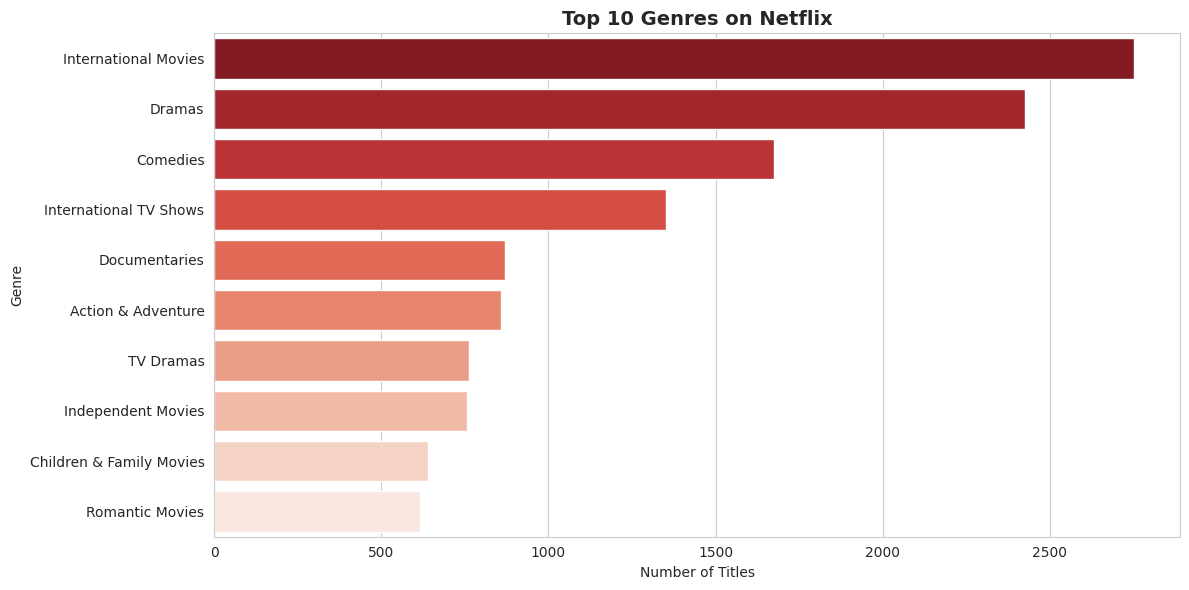

Chart 5 saved! ✅


In [20]:
# Genres — listed_in has multiple genres per title
# Split and explode!
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values,
            y=top_genres.index,
            hue=top_genres.index,
            palette='Reds_r')

plt.title("Top 10 Genres on Netflix",
          fontweight='bold', fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig('screenshots/05_top_genres.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 5 saved! ✅")

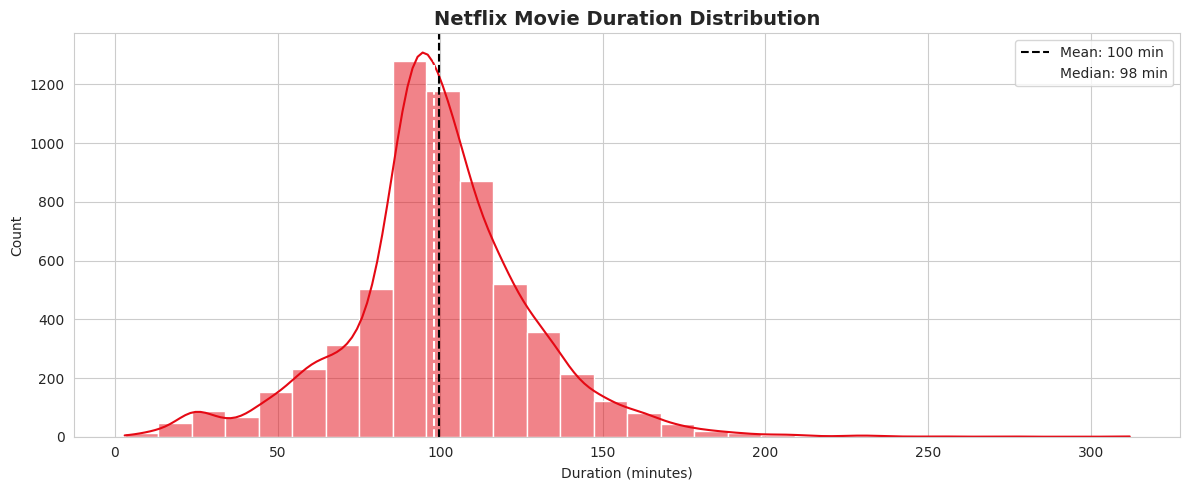

Chart 6 saved! ✅


In [21]:
# Movie duration distribution
movies = df[df['type'] == 'Movie']

plt.figure(figsize=(12, 5))
sns.histplot(data=movies, x='duration_value',
             bins=30, kde=True, color='#E50914')

plt.axvline(movies['duration_value'].mean(),
            color='black', linestyle='--',
            label=f"Mean: {movies['duration_value'].mean():.0f} min")
plt.axvline(movies['duration_value'].median(),
            color='white', linestyle='--',
            label=f"Median: {movies['duration_value'].median():.0f} min")

plt.title("Netflix Movie Duration Distribution",
          fontweight='bold', fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/06_movie_duration.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 6 saved! ✅")

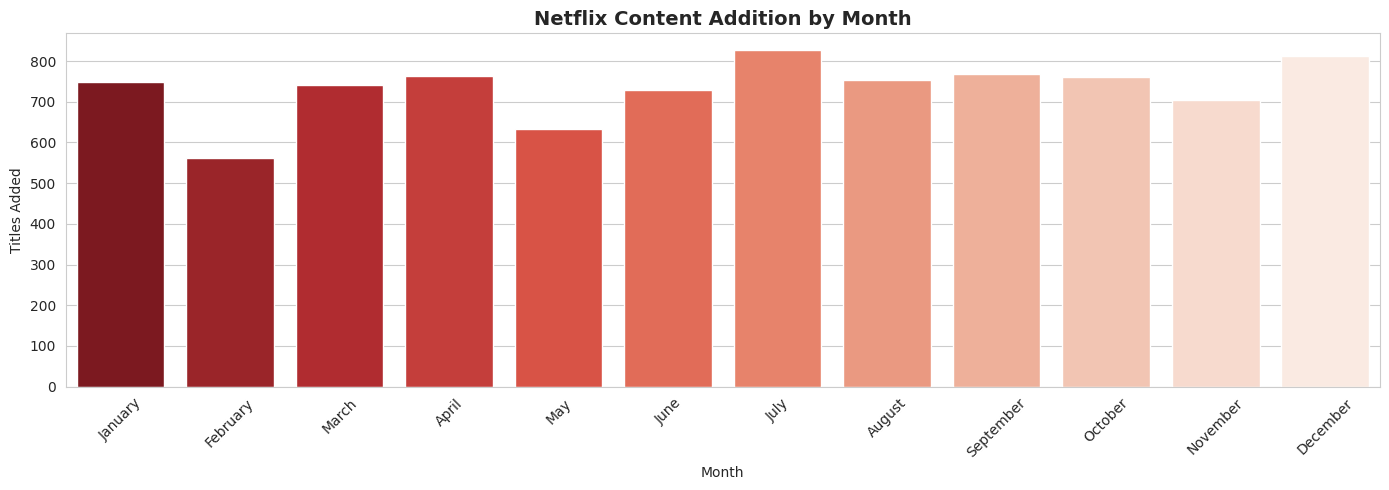

Chart 7 saved! ✅


In [22]:
# Which month does Netflix add most content?
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

monthly = df['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(14, 5))
sns.barplot(x=monthly.index, y=monthly.values,
            hue=monthly.index,
            palette='Reds_r')

plt.title("Netflix Content Addition by Month",
          fontweight='bold', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Titles Added")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('screenshots/07_monthly_additions.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 7 saved! ✅")

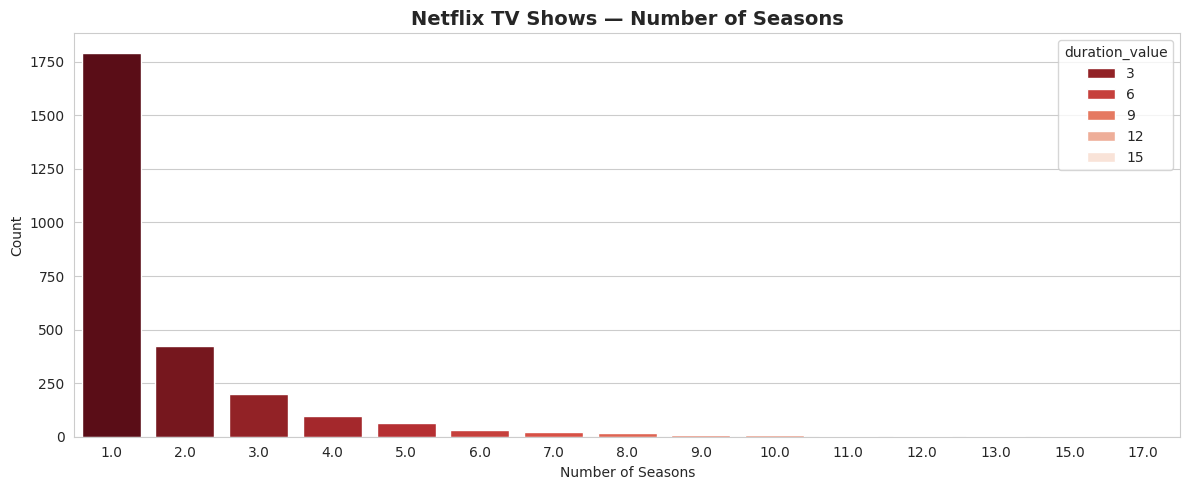

Chart 8 saved! ✅


In [23]:
# TV Show seasons
shows = df[df['type'] == 'TV Show']

plt.figure(figsize=(12, 5))
sns.countplot(data=shows,
              x='duration_value',
              hue='duration_value',
              palette='Reds_r',
              order=sorted(shows['duration_value'].dropna().unique()))

plt.title("Netflix TV Shows — Number of Seasons",
          fontweight='bold', fontsize=14)
plt.xlabel("Number of Seasons")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('screenshots/08_tv_seasons.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 8 saved! ✅")

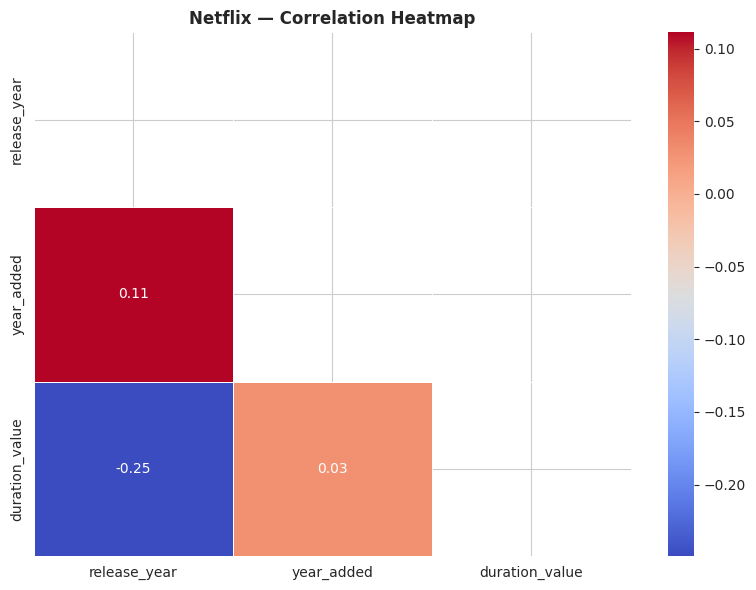

Chart 9 saved! ✅


In [24]:
# Correlation heatmap
numerical = ['release_year', 'year_added', 'duration_value']
corr = df[numerical].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', mask=mask,
            linewidths=0.5)
plt.title("Netflix — Correlation Heatmap",
          fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/09_correlation.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Chart 9 saved! ✅")

In [25]:
# Hypothesis Test — Do Movies and TV Shows differ in release year?
movies_year = df[df['type']=='Movie']['release_year']
shows_year = df[df['type']=='TV Show']['release_year']

t_stat, p_value = stats.ttest_ind(movies_year, shows_year)

print("=== Hypothesis Test ===")
print(f"H₀: Movies and TV Shows have same avg release year")
print(f"H₁: They differ!")
print(f"\nMovie avg release year:   {movies_year.mean():.1f}")
print(f"TV Show avg release year: {shows_year.mean():.1f}")
print(f"\nP-value: {p_value:.6f}")

if p_value < 0.05:
    print("→ REJECT H₀! Significant difference!")
else:
    print("→ FAIL TO REJECT H₀!")

=== Hypothesis Test ===
H₀: Movies and TV Shows have same avg release year
H₁: They differ!

Movie avg release year:   2013.1
TV Show avg release year: 2016.6

P-value: 0.000000
→ REJECT H₀! Significant difference!


In [26]:
from google.colab import files

# Download all screenshots
import os
for file in os.listdir('screenshots'):
    files.download(f'screenshots/{file}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.9 MB/s eta 0:00:00


In [29]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

def generate_pdf_report():
    doc = SimpleDocTemplate("netflix_report.pdf", pagesize=letter)
    styles = getSampleStyleSheet()
    story = []

    # Title
    story.append(Paragraph("Netflix Content Analysis Report", styles['Title']))
    story.append(Paragraph("Analyst: Prajwal Kondala | IIT Kharagpur", styles['Normal']))
    story.append(Spacer(1, 20))

    # Overview Table
    story.append(Paragraph("Dataset Overview", styles['Heading1']))
    overview_data = [
        ['Metric', 'Value'],
        ['Total Titles', f"{len(df):,}"],
        ['Movies', f"{df[df['type']=='Movie'].shape[0]:,}"],
        ['TV Shows', f"{df[df['type']=='TV Show'].shape[0]:,}"],
        ['Countries', f"{df['primary_country'].nunique()}"],
        ['Year Range', f"{int(df['release_year'].min())} - {int(df['release_year'].max())}"],
        ['Avg Movie Duration', f"{df[df['type']=='Movie']['duration_value'].mean():.0f} mins"],
    ]
    table = Table(overview_data)
    table.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#E50914')),
        ('TEXTCOLOR', (0,0), (-1,0), colors.white),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('GRID', (0,0), (-1,-1), 1, colors.black),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.lightgrey]),
    ]))
    story.append(table)
    story.append(Spacer(1, 20))

    # Key Insights
    story.append(Paragraph("Key Business Insights", styles['Heading1']))
    insights = [
        "1. Movies dominate Netflix — 69.6% of all content!",
        "2. 2019 was peak content addition year — pre-COVID!",
        "3. USA and India are top content producing countries",
        "4. TV-MA rating dominates — Netflix targets adult audience",
        "5. International Movies is #1 genre — global strategy working!",
        "6. Average Netflix movie duration — 100 minutes",
        "7. 75% of TV Shows have only 1 season — high cancellation rate!",
        "8. July, September, December — peak content addition months",
    ]
    for insight in insights:
        story.append(Paragraph(insight, styles['Normal']))
        story.append(Spacer(1, 8))

    doc.build(story)
    print("✅ Netflix PDF Report generated!")

generate_pdf_report()

✅ Netflix PDF Report generated!


In [30]:
from google.colab import files
files.download('netflix_report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>